# 05. LPIPS Single-Image Case Studies

This notebook is for close inspection of individual images.

It supports two use cases:

1. Load local images.
2. Auto-pick frog and horse examples from CIFAR10.

Questions answered here:

- How do LPIPS and MSE react to noise, blur, downsampling, and shift on one specific image?
- If one frog or horse image gives a visibly bad reconstruction, can we see that clearly?


In [ ]:
!pip install torch torchvision lpips matplotlib pandas pillow seaborn

import io
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset

import lpips

sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "generated_figures"
FIG_DIR.mkdir(exist_ok=True)
print("Using device:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.8 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# Reproducibility helps make LPIPS-vs-MSE comparisons fair.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
STL10_CLASSES = CIFAR10_CLASSES

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def to_lpips_range(x):
    return x * 2.0 - 1.0


def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2, dim=(1, 2, 3))
    return 10.0 * torch.log10(1.0 / (mse + 1e-8))


def build_transform(image_size: int):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
    ])


def degrade_image(image: torch.Tensor, mode: str):
    image = image.clone()
    if mode == "identity":
        return image
    if mode == "gaussian_noise":
        noise = 0.08 * torch.randn_like(image)
        return torch.clamp(image + noise, 0.0, 1.0)
    if mode == "blur":
        return TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[1.2, 1.2])
    if mode == "downsample":
        h, w = image.shape[-2:]
        small = TF.resize(image, [max(8, h // 4), max(8, w // 4)], antialias=True)
        return TF.resize(small, [h, w], antialias=True)
    if mode == "shift":
        return torch.roll(image, shifts=(2, 2), dims=(1, 2))
    raise ValueError(f"Unknown degradation mode: {mode}")


class ReconstructionWrapper(Dataset):
    def __init__(self, base_dataset, degradation="identity"):
        self.base_dataset = base_dataset
        self.degradation = degradation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        image = sample[0] if isinstance(sample, tuple) else sample
        degraded = degrade_image(image, self.degradation)
        return degraded, image


class RepeatedSingleImageDataset(Dataset):
    def __init__(self, image: torch.Tensor, repeats=256, degradation="identity"):
        self.image = image
        self.repeats = repeats
        self.degradation = degradation

    def __len__(self):
        return self.repeats

    def __getitem__(self, idx):
        return degrade_image(self.image, self.degradation), self.image


def get_dataset(dataset_name: str, image_size: int):
    transform = build_transform(image_size)
    name = dataset_name.upper()
    if name == "CIFAR10":
        return torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "CIFAR100":
        return torchvision.datasets.CIFAR100(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "STL10":
        return torchvision.datasets.STL10(root=str(DATA_DIR), split="train", download=True, transform=transform)
    if name == "CELEBA":
        return torchvision.datasets.CelebA(root=str(DATA_DIR), split="train", download=True, transform=transform)
    raise ValueError(f"Unsupported dataset: {dataset_name}")


def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return [int(x) for x in dataset.targets]
    if hasattr(dataset, "labels"):
        return [int(x) for x in dataset.labels]
    return None


def filter_by_class(dataset, dataset_name: str, class_name: str, max_items=1000):
    if class_name == "all":
        return dataset
    targets = get_targets(dataset)
    if targets is None:
        raise ValueError(f"Dataset {dataset_name} does not expose simple class labels for filtering.")
    if dataset_name.upper() == "CIFAR10":
        class_index = CIFAR10_CLASSES.index(class_name)
    elif dataset_name.upper() == "STL10":
        class_index = STL10_CLASSES.index(class_name)
    else:
        raise ValueError(f"Class filtering not set up for {dataset_name}.")
    indices = [i for i, target in enumerate(targets) if target == class_index][:max_items]
    return Subset(dataset, indices)


def train_two_models(train_loader, epochs=5, lpips_net="vgg"):
    base_model = ConvAutoencoder().to(DEVICE)
    model_lpips = ConvAutoencoder().to(DEVICE)
    model_mse = ConvAutoencoder().to(DEVICE)
    model_lpips.load_state_dict(base_model.state_dict())
    model_mse.load_state_dict(base_model.state_dict())

    optimizer_lpips = optim.Adam(model_lpips.parameters(), lr=1e-4)
    optimizer_mse = optim.Adam(model_mse.parameters(), lr=1e-4)
    lpips_loss = lpips.LPIPS(net=lpips_net).to(DEVICE).eval()
    mse_loss = nn.MSELoss()

    history = {"epoch": [], "lpips_train_loss": [], "mse_train_loss": []}
    for epoch in range(1, epochs + 1):
        model_lpips.train()
        model_mse.train()
        running_lpips = 0.0
        running_mse = 0.0
        batches = 0

        for degraded, clean in train_loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)

            optimizer_lpips.zero_grad()
            pred_lpips = model_lpips(degraded)
            loss_lp = lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean()
            loss_lp.backward()
            optimizer_lpips.step()

            optimizer_mse.zero_grad()
            pred_mse = model_mse(degraded)
            loss_mse = mse_loss(pred_mse, clean)
            loss_mse.backward()
            optimizer_mse.step()

            running_lpips += loss_lp.item()
            running_mse += loss_mse.item()
            batches += 1

        history["epoch"].append(epoch)
        history["lpips_train_loss"].append(running_lpips / batches)
        history["mse_train_loss"].append(running_mse / batches)
        print(f"Epoch {epoch:02d} | LPIPS: {history['lpips_train_loss'][-1]:.4f} | MSE: {history['mse_train_loss'][-1]:.4f}")

    return model_lpips, model_mse, pd.DataFrame(history), lpips_loss, mse_loss


def evaluate_models(model_lpips, model_mse, loader, lpips_loss, mse_loss):
    model_lpips.eval()
    model_mse.eval()
    rows = []
    with torch.no_grad():
        for degraded, clean in loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)
            pred_lpips = model_lpips(degraded)
            pred_mse = model_mse(degraded)
            rows.append({
                "lpips_model_lpips": lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean().item(),
                "mse_model_lpips": lpips_loss(to_lpips_range(pred_mse), to_lpips_range(clean)).mean().item(),
                "lpips_model_mse": mse_loss(pred_lpips, clean).item(),
                "mse_model_mse": mse_loss(pred_mse, clean).item(),
                "lpips_model_psnr": psnr(pred_lpips, clean).mean().item(),
                "mse_model_psnr": psnr(pred_mse, clean).mean().item(),
            })
    return pd.DataFrame(rows).mean().to_frame(name="value")


def show_reconstructions(model_lpips, model_mse, loader, title, n=5):
    degraded, clean = next(iter(loader))
    degraded = degraded.to(DEVICE)
    clean = clean.to(DEVICE)
    with torch.no_grad():
        pred_lpips = model_lpips(degraded).cpu()
        pred_mse = model_mse(degraded).cpu()
    degraded = degraded.cpu()
    clean = clean.cpu()

    n = min(n, degraded.size(0))
    plt.figure(figsize=(3 * n, 8))
    for i in range(n):
        plt.subplot(4, n, i + 1)
        plt.imshow(degraded[i].permute(1, 2, 0))
        plt.title("Input")
        plt.axis("off")

        plt.subplot(4, n, n + i + 1)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.title("Target")
        plt.axis("off")

        plt.subplot(4, n, 2 * n + i + 1)
        plt.imshow(pred_lpips[i].permute(1, 2, 0))
        plt.title("LPIPS")
        plt.axis("off")

        plt.subplot(4, n, 3 * n + i + 1)
        plt.imshow(pred_mse[i].permute(1, 2, 0))
        plt.title("MSE")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
IMAGE_SIZE = 128
DISTORTIONS = ["identity", "gaussian_noise", "blur", "downsample", "shift"]
LPIPS_NET = "vgg"
EPOCHS = 200
BATCH_SIZE = 32
REPEATS = 256

# Option A: set local paths here. If left as None, the notebook will auto-load from CIFAR10.
LOCAL_FROG_PATH = None
LOCAL_HORSE_PATH = None


100%|██████████| 170M/170M [00:02<00:00, 75.8MB/s]


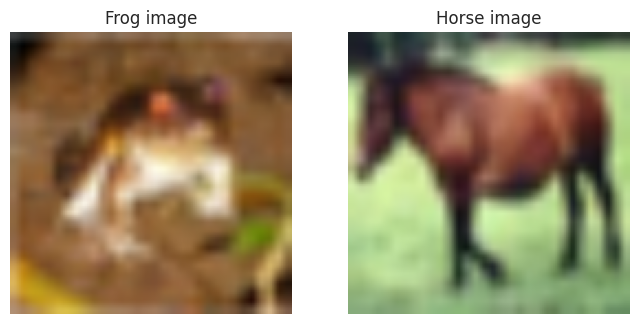

In [ ]:
def load_local_image(path, image_size=128):
    image = Image.open(path).convert("RGB")
    return build_transform(image_size)(image)


def get_first_cifar10_image(class_name: str, image_size=128):
    dataset = get_dataset("CIFAR10", image_size)
    dataset = filter_by_class(dataset, "CIFAR10", class_name, max_items=1)
    sample = dataset[0]
    return sample[0]


def select_image(local_path, class_name, image_size):
    if local_path is not None and Path(local_path).exists():
        return load_local_image(local_path, image_size=image_size)
    return get_first_cifar10_image(class_name, image_size=image_size)

frog_image = select_image(LOCAL_FROG_PATH, "frog", IMAGE_SIZE)
horse_image = select_image(LOCAL_HORSE_PATH, "horse", IMAGE_SIZE)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(frog_image.permute(1, 2, 0))
plt.title("Frog image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(horse_image.permute(1, 2, 0))
plt.title("Horse image")
plt.axis("off")
plt.show()


In [ ]:
# Metric-only analysis first: compare LPIPS and MSE directly across distortions.
metric_models = {
    "vgg": lpips.LPIPS(net="vgg").to(DEVICE).eval(),
}
mse_loss = nn.MSELoss()

single_rows = []
for image_name, image_tensor in {"frog": frog_image, "horse": horse_image}.items():
    ref = image_tensor.unsqueeze(0).to(DEVICE)
    for distortion in DISTORTIONS:
        distorted = degrade_image(image_tensor, distortion).unsqueeze(0).to(DEVICE)
        single_rows.append({
            "image": image_name,
            "distortion": distortion,
            "lpips_vgg": metric_models["vgg"](to_lpips_range(distorted), to_lpips_range(ref)).mean().item(),
            "mse": mse_loss(distorted, ref).item(),
            "psnr": psnr(distorted, ref).mean().item(),
        })

single_df = pd.DataFrame(single_rows)
single_df


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 73.8MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


,image,distortion,lpips_vgg,mse,psnr
0,frog,identity,0.000000,0.000000,80.000000
1,frog,gaussian_noise,0.593049,0.006268,22.028805
2,frog,blur,0.025299,0.000053,42.766602
3,frog,downsample,0.100553,0.000479,33.200249
4,frog,shift,0.196941,0.004725,23.256416
5,horse,identity,0.000000,0.000000,80.000000
6,horse,gaussian_noise,0.470681,0.006251,22.040461
7,horse,blur,0.015823,0.000087,40.607880
8,horse,downsample,0.052049,0.000837,30.771164
9,horse,shift,0.147400,0.007150,21.456900


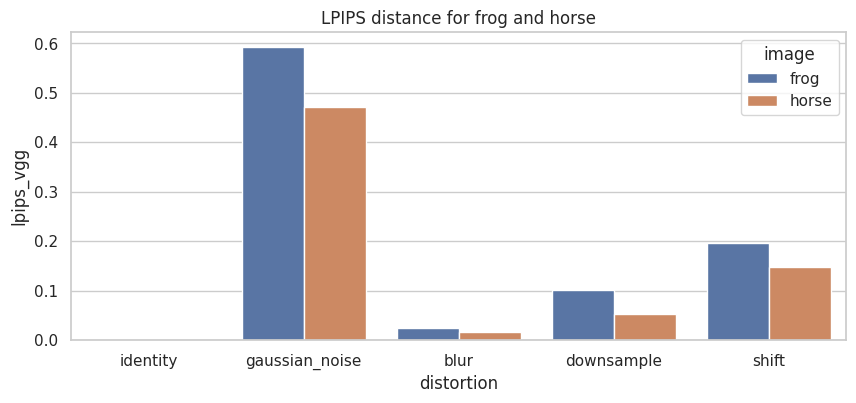

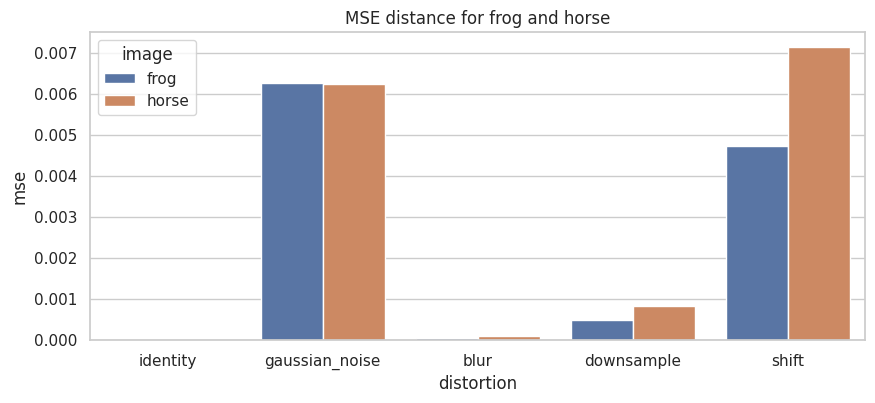

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=single_df, x="distortion", y="lpips_vgg", hue="image")
plt.title("LPIPS distance for frog and horse")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=single_df, x="distortion", y="mse", hue="image")
plt.title("MSE distance for frog and horse")
plt.show()


In [ ]:
# Optional: train repeated-image reconstruction on one image.
TARGET_IMAGE_NAME = "frog"   # Try "horse"
TARGET_DISTORTION = "downsample"

target_image = frog_image if TARGET_IMAGE_NAME == "frog" else horse_image
train_dataset = RepeatedSingleImageDataset(target_image, repeats=REPEATS, degradation=TARGET_DISTORTION)
val_dataset = RepeatedSingleImageDataset(target_image, repeats=64, degradation=TARGET_DISTORTION)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model_lpips, model_mse, history_df, lpips_loss, mse_loss = train_two_models(train_loader, epochs=EPOCHS, lpips_net=LPIPS_NET)
metrics = evaluate_models(model_lpips, model_mse, val_loader, lpips_loss, mse_loss)
metrics


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Epoch 01 | LPIPS: 0.9246 | MSE: 0.0468
Epoch 02 | LPIPS: 0.9216 | MSE: 0.0462
Epoch 03 | LPIPS: 0.9181 | MSE: 0.0450
Epoch 04 | LPIPS: 0.9142 | MSE: 0.0424
Epoch 05 | LPIPS: 0.9083 | MSE: 0.0364
Epoch 06 | LPIPS: 0.8946 | MSE: 0.0301
Epoch 07 | LPIPS: 0.8414 | MSE: 0.0286
Epoch 08 | LPIPS: 0.7334 | MSE: 0.0274
Epoch 09 | LPIPS: 0.6484 | MSE: 0.0268
Epoch 10 | LPIPS: 0.6236 | MSE: 0.0260
Epoch 11 | LPIPS: 0.6149 | MSE: 0.0249
Epoch 12 | LPIPS: 0.6095 | MSE: 0.0231
Epoch 13 | LPIPS: 0.6045 | MSE: 0.0201
Epoch 14 | LPIPS: 0.6006 | MSE: 0.0162
Epoch 15 | LPIPS: 0.5964 | MSE: 0.0134
Epoch 16 | LPIPS: 0.5921 | MSE: 0.0108
Epoch 17 | LPIPS: 0.5873 | MSE: 0.0077
Epoch 18 | LPIPS: 0.5817 | MSE: 0.0059
Epoch 19 | LPIPS: 0.5744 | MSE: 0.0048
Epoch 20 | LPIPS: 0.5662 | MSE: 0.0042
Epoch 21 | LPIPS: 0.5576 | MSE: 0.0037
Epoch 22 | LPIPS: 0.5461 | MSE: 0.0034
Epoch 23 | LPIPS: 0.5371 | MSE: 0.0031
Epoch 24 | LPIPS

,value
lpips_model_lpips,0.054958
mse_model_lpips,0.159161
lpips_model_mse,0.007761
mse_model_mse,0.000329
lpips_model_psnr,21.100836
mse_model_psnr,34.827599


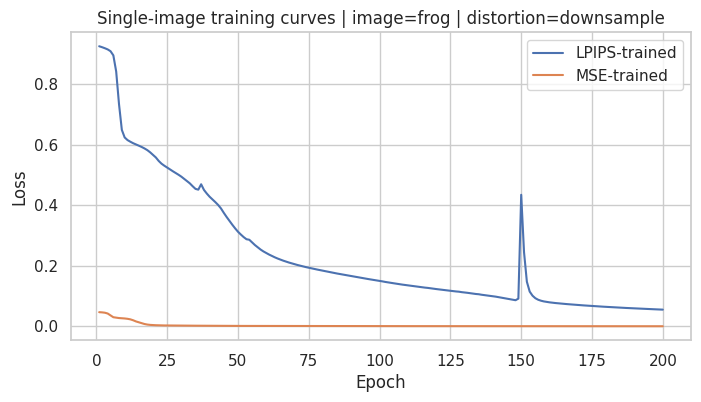

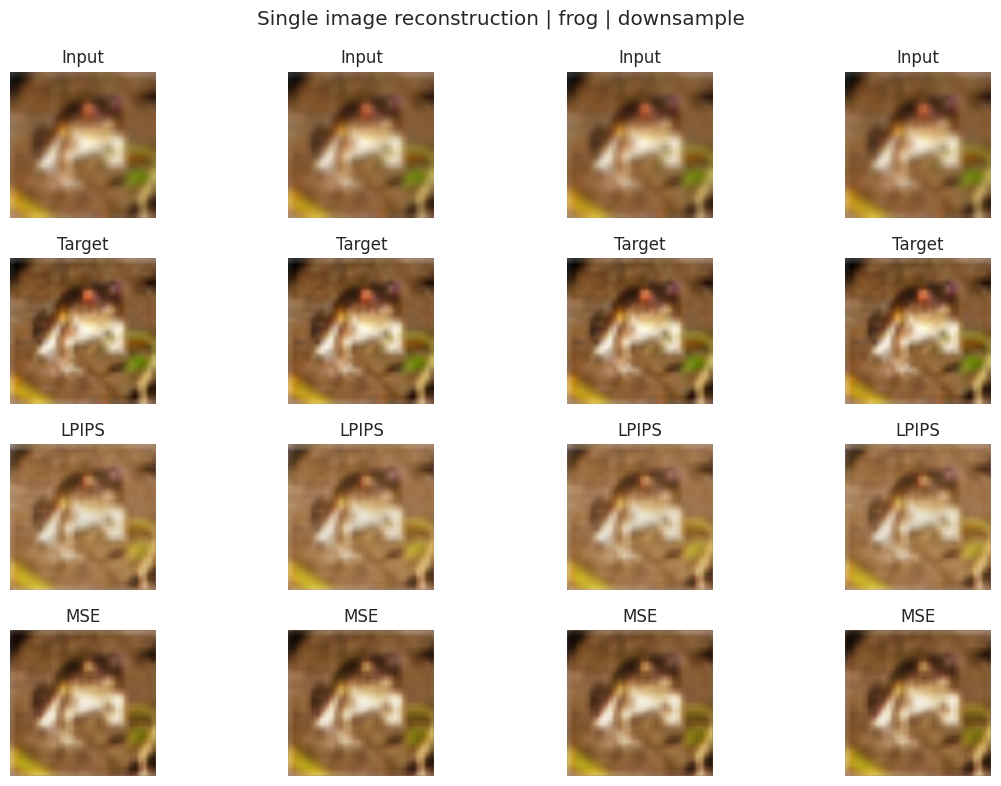

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["lpips_train_loss"], label="LPIPS-trained")
plt.plot(history_df["epoch"], history_df["mse_train_loss"], label="MSE-trained")
plt.title(f"Single-image training curves | image={TARGET_IMAGE_NAME} | distortion={TARGET_DISTORTION}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

show_reconstructions(model_lpips, model_mse, val_loader, title=f"Single image reconstruction | {TARGET_IMAGE_NAME} | {TARGET_DISTORTION}", n=4)
